# 06 - GRU Forecasting

Notebook nay tach theo tung cell de ban de quan ly va sua:
- setup GPU / Colab
- clone repo + setup path
- import
- config
- prepare data
- build model
- train
- evaluate
- visualize
- export


In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import tensorflow as tf
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available:", tf.config.list_physical_devices('GPU'))

Built with CUDA: True
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. GPU check

Neu chay tren Colab, hay bat `Runtime > Change runtime type > T4 GPU` truoc.


In [3]:
import os
import tensorflow as tf

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus)

if '/content' in os.getcwd() and not gpus:
    raise RuntimeError(
        'No GPU detected in Colab. Go to Runtime > Change runtime type > T4 GPU, then rerun from the top.'
    )

if gpus:
    try:
        print('GPU name:', tf.config.experimental.get_device_details(gpus[0]).get('device_name', '<unknown>'))
    except Exception as exc:
        print('Could not read GPU name:', exc)


TensorFlow version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU name: Tesla T4


## 2. Repo bootstrap

Cell nay se clone repo neu dang chay tren Colab. Neu chay local trong repo thi no se tu tim project root hien tai.


In [4]:
# import os
# import subprocess
# import sys
# from pathlib import Path

# REPO_URL = 'https://github.com/HoangHumg1210/hoankiem-air-quality-.git'
# REPO_NAME = 'hoankiem-air-quality-forecasting'

# cwd = Path.cwd().resolve()
# if str(cwd).startswith('/content'):
#     project_root = Path('/content') / REPO_NAME
#     os.chdir('/content')
#     if not project_root.exists():
#         subprocess.run(['git', 'clone', REPO_URL, REPO_NAME], check=True)
# else:
#     project_root = cwd if (cwd / 'src').exists() else cwd.parent

# os.chdir(project_root)
# if str(project_root) not in sys.path:
#     sys.path.insert(0, str(project_root))

# required_paths = [
#     project_root / 'src' / 'data_utils.py',
#     project_root / 'data' / 'processed' / 'data2225_done.csv',
# ]
# missing_paths = [str(path) for path in required_paths if not path.exists()]
# if missing_paths:
#     raise FileNotFoundError('Missing required project files: ' + ', '.join(missing_paths))

# print('PROJECT_ROOT =', project_root)
# print('sys.path[0] =', sys.path[0])
%cd /content

!rm -rf hoankiem-air-quality-forecasting

!git clone https://github.com/HoangHumg1210/hoankiem-air-quality-forecasting.git

%cd hoankiem-air-quality-forecasting

!ls

/content
Cloning into 'hoankiem-air-quality-forecasting'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 112 (delta 53), reused 79 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 8.98 MiB | 4.52 MiB/s, done.
Resolving deltas: 100% (53/53), done.
/content/hoankiem-air-quality-forecasting
data  notebooks  requirements.txt  src	tests  test_walkforward_data_utils.py


## 3. Imports

Neu import package nao fail, ban moi can cai them package do.


In [5]:
from dataclasses import dataclass
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.optimizers import Adam

from src.data_utils import (
    CFG,
    evaluate_by_horizon,
    evaluate_regression,
    inverse_y,
    prepare_dataset,
    set_seed,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
print('Imports OK')


Imports OK


In [11]:
!nvidia-smi

Thu Mar 19 14:29:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P0             29W /   70W |     109MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4. Configs

Sua cell nay de doi hyperparameters cho smoke run hoac full training.


In [8]:
@dataclass
class GRUExperimentConfig:
    gru_units: tuple[int, ...] = (128, 64)
    dense_units: Optional[int] = 64
    dropout: float = 0.2
    learning_rate: float = 1e-3
    batch_size: int = 64
    epochs: int = 30
    patience: int = 8
    min_lr: float = 1e-5
    step_to_plot: int = 1
    confidence_z: float = 1.96

data_cfg = CFG

smoke_cfg = GRUExperimentConfig(
    gru_units=(64,),
    dense_units=32,
    dropout=0.1,
    batch_size=128,
    epochs=10,
    patience=2,
)

full_cfg = GRUExperimentConfig(
    gru_units=(128, 64),
    dense_units=64,
    dropout=0.2,
    batch_size=64,
    epochs=30,
    patience=8,
)

print(data_cfg)
print('Smoke config:', smoke_cfg)
print('Full config :', full_cfg)


DataConfig(data_path='data/processed/data2225_done.csv', target='PM25', time_col='Local Time', lookback=336, horizon=72, target_transform='log', train_end='2023-12-31 23:00:00', val_start='2024-01-01 00:00:00', val_end='2024-12-31 23:00:00', test_start='2025-01-01 00:00:00', freq='1h', seed=42)
Smoke config: GRUExperimentConfig(gru_units=(64,), dense_units=32, dropout=0.1, learning_rate=0.001, batch_size=128, epochs=10, patience=2, min_lr=1e-05, step_to_plot=1, confidence_z=1.96)
Full config : GRUExperimentConfig(gru_units=(128, 64), dense_units=64, dropout=0.2, learning_rate=0.001, batch_size=64, epochs=30, patience=8, min_lr=1e-05, step_to_plot=1, confidence_z=1.96)


## 5. Prepare data

Cell nay chay pipeline `prepare_dataset()` va cho ban thay ngay shape train / val / test.


In [9]:
set_seed(data_cfg.seed)
artifacts = prepare_dataset(data_cfg)

print('Train seq:', artifacts['X_train_seq'].shape, artifacts['y_train_seq'].shape)
print('Val seq  :', artifacts['X_val_seq'].shape, artifacts['y_val_seq'].shape)
print('Test seq :', artifacts['X_test_seq'].shape, artifacts['y_test_seq'].shape)
print('n_features:', artifacts['n_features'])


Loaded df: (34769, 16)
After feature engineering: (34697, 35)
Train: (17153, 35)
Val  : (8784, 35)
Test : (8760, 35)
X_train: (17153, 43) y_train: (17153, 1)
X_val  : (8784, 43) y_val  : (8784, 1)
X_test : (8760, 43) y_test : (8760, 1)
Sequence shapes:
Train: (16746, 336, 43) (16746, 72)
Val  : (8713, 336, 43) (8713, 72)
Test : (8689, 336, 43) (8689, 72)
n_features = 43
Train seq: (16746, 336, 43) (16746, 72)
Val seq  : (8713, 336, 43) (8713, 72)
Test seq : (8689, 336, 43) (8689, 72)
n_features: 43


## 6. Build GRU model

Neu muon doi architecture, ban sua cell function nay.


In [10]:
def build_gru_model(input_shape: tuple[int, int], horizon: int, cfg: GRUExperimentConfig) -> Model:
    model = Sequential(name='gru_forecaster')
    model.add(Input(shape=input_shape))

    for idx, units in enumerate(cfg.gru_units):
        return_sequences = idx < len(cfg.gru_units) - 1
        model.add(GRU(units, return_sequences=return_sequences))
        if cfg.dropout > 0:
            model.add(Dropout(cfg.dropout))

    if cfg.dense_units is not None:
        model.add(Dense(cfg.dense_units, activation='relu'))
        if cfg.dropout > 0:
            model.add(Dropout(cfg.dropout))

    model.add(Dense(horizon, name='forecast'))
    model.compile(
        optimizer=Adam(learning_rate=cfg.learning_rate),
        loss='mse',
        metrics=['mae'],
    )
    return model

model_preview = build_gru_model(
    input_shape=(artifacts['cfg'].lookback, artifacts['n_features']),
    horizon=artifacts['cfg'].horizon,
    cfg=full_cfg,
)
model_preview.summary()


Model: "gru_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 336, 128)       │        66,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 336, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Dense)                │ (None, 72)             │         4,680 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,520 (439.53 KB)

 Trainable params: 112,520 (439.53 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train helpers

Cell nay tach rieng logic train de ban de thay callback va data train / val.


In [12]:
def train_gru_model(artifacts: dict, cfg: GRUExperimentConfig):
    model = build_gru_model(
        input_shape=(artifacts['cfg'].lookback, artifacts['n_features']),
        horizon=artifacts['cfg'].horizon,
        cfg=cfg,
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=cfg.patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=max(2, cfg.patience // 2),
            min_lr=cfg.min_lr,
            verbose=1,
        ),
    ]

    history = model.fit(
        artifacts['X_train_seq'],
        artifacts['y_train_seq'],
        validation_data=(artifacts['X_val_seq'], artifacts['y_val_seq']),
        epochs=cfg.epochs,
        batch_size=cfg.batch_size,
        callbacks=callbacks,
        verbose=1,
    )
    return model, history


## 8. Evaluate helpers

Cell nay tach rieng phan predict, metric va tao bang forecast.


In [13]:
def predict_split(model: Model, artifacts: dict, split: str = 'test'):
    X_seq = artifacts[f'X_{split}_seq']
    y_seq = artifacts[f'y_{split}_seq']
    times = pd.DatetimeIndex(artifacts[f'{split}_times'])

    y_pred_scaled = model.predict(X_seq, verbose=0)
    y_pred = inverse_y(y_pred_scaled, artifacts['target_transformer'])
    y_true = inverse_y(y_seq, artifacts['target_transformer'])
    return y_true, y_pred, times

def build_forecast_frame(y_true, y_pred, times, step=1, residual_std=None, confidence_z=1.96):
    step_idx = step - 1
    frame = pd.DataFrame({
        'time': pd.DatetimeIndex(times),
        'actual': y_true[:, step_idx],
        'predicted': y_pred[:, step_idx],
    })
    if residual_std is not None:
        half_width = confidence_z * residual_std
        frame['lower'] = np.clip(frame['predicted'] - half_width, 0, None)
        frame['upper'] = frame['predicted'] + half_width
    return frame

def evaluate_predictions(model: Model, artifacts: dict, split: str = 'test', plot_step: int = 1, confidence_z: float = 1.96):
    y_true, y_pred, times = predict_split(model, artifacts, split=split)
    metrics_all = evaluate_regression(y_true, y_pred, name=f'{split.upper()}(all horizons)')
    metrics_step = evaluate_regression(y_true[:, 0], y_pred[:, 0], name=f'{split.upper()}(step 1)')
    by_horizon = evaluate_by_horizon(y_true, y_pred)

    residual_std = None
    if split == 'test':
        y_true_val, y_pred_val, _ = predict_split(model, artifacts, split='val')
        residual_std = float(np.std(y_true_val[:, plot_step - 1] - y_pred_val[:, plot_step - 1]))

    forecast_frame = build_forecast_frame(
        y_true=y_true,
        y_pred=y_pred,
        times=times,
        step=plot_step,
        residual_std=residual_std,
        confidence_z=confidence_z,
    )

    metrics_frame = pd.DataFrame([
        {'split': split, 'scope': 'all_horizons', **metrics_all},
        {'split': split, 'scope': f'step_{plot_step}', **metrics_step},
    ])

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'times': times,
        'metrics_all': metrics_all,
        'metrics_step': metrics_step,
        'metrics_frame': metrics_frame,
        'by_horizon': by_horizon,
        'forecast_frame': forecast_frame,
    }


## 9. Plot helpers

Cell nay gom toan bo phan visualize de ban de doi style plot.


In [14]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    history_df = pd.DataFrame(history.history)

    history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].grid(True, alpha=0.3)

    history_df[['mae', 'val_mae']].plot(ax=axes[1], title='MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    return fig

def plot_forecast(forecast_frame: pd.DataFrame, title: str = 'GRU forecast on test'):
    plot_df = forecast_frame.copy().sort_values('time')
    plot_df['time'] = pd.to_datetime(plot_df['time'])
    plot_df = plot_df.set_index('time')

    daily_df = plot_df.resample('1D').mean(numeric_only=True)
    recent_days = min(45, max(7, int(np.ceil(len(plot_df) / 24 / 4))))
    recent_start = plot_df.index.max() - pd.Timedelta(days=recent_days)
    recent_df = plot_df.loc[plot_df.index >= recent_start].copy()
    smooth_window = min(24, max(3, len(recent_df) // 20))
    recent_df['actual_smooth'] = recent_df['actual'].rolling(smooth_window, min_periods=1).mean()
    recent_df['predicted_smooth'] = recent_df['predicted'].rolling(smooth_window, min_periods=1).mean()

    fig, axes = plt.subplots(2, 1, figsize=(15, 9), gridspec_kw={'height_ratios': [1.15, 1.0]})

    axes[0].plot(daily_df.index, daily_df['actual'], label='Actual daily mean', linewidth=2.5, color='#1f77b4')
    axes[0].plot(daily_df.index, daily_df['predicted'], label='GRU daily mean', linewidth=2.5, color='#ff7f0e')
    if {'lower', 'upper'}.issubset(daily_df.columns):
        axes[0].fill_between(daily_df.index, daily_df['lower'], daily_df['upper'], color='#ff7f0e', alpha=0.12, label='Approx. interval')
    axes[0].set_title(f'{title} - full test (daily mean)')
    axes[0].set_ylabel('PM2.5')
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(loc='upper left', ncol=3, frameon=True)

    axes[1].plot(recent_df.index, recent_df['actual'], linewidth=0.9, color='#1f77b4', alpha=0.25, label='Actual hourly')
    axes[1].plot(recent_df.index, recent_df['actual_smooth'], linewidth=2.5, color='#1f77b4', label=f'Actual smooth ({smooth_window}h)')
    axes[1].plot(recent_df.index, recent_df['predicted_smooth'], linewidth=2.5, color='#ff7f0e', label=f'GRU smooth ({smooth_window}h)')
    if {'lower', 'upper'}.issubset(recent_df.columns):
        axes[1].fill_between(recent_df.index, recent_df['lower'], recent_df['upper'], color='#ff7f0e', alpha=0.10, label='Approx. interval')
    axes[1].set_title(f'Recent zoom ({recent_days} days)')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('PM2.5')
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(loc='upper left', ncol=4, frameon=True)

    fig.tight_layout()
    return fig


## 10. Smoke run

Chay cell nay truoc de bat loi moi truong / path / GPU.


In [15]:
smoke_model, smoke_history = train_gru_model(artifacts, smoke_cfg)
smoke_val = evaluate_predictions(smoke_model, artifacts, split='val', plot_step=smoke_cfg.step_to_plot, confidence_z=smoke_cfg.confidence_z)
smoke_test = evaluate_predictions(smoke_model, artifacts, split='test', plot_step=smoke_cfg.step_to_plot, confidence_z=smoke_cfg.confidence_z)
smoke_metrics = pd.concat([smoke_val['metrics_frame'], smoke_test['metrics_frame']], ignore_index=True)
smoke_metrics


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.6776 - mae: 0.6461 - val_loss: 0.6847 - val_mae: 0.6616 - learning_rate: 0.0010
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.4836 - mae: 0.5493 - val_loss: 0.6415 - val_mae: 0.6348 - learning_rate: 0.0010
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.4312 - mae: 0.5182 - val_loss: 0.7312 - val_mae: 0.6668 - learning_rate: 0.0010
Epoch 4/10
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3953 - mae: 0.4953
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.3871 - mae: 0.4898 - val_loss: 0.8228 - val_mae: 0.7062 - learning_rate: 0.0010
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.
VAL(all horizons) MAE : 9.1068
VAL(all horizons) MSE : 193.9572
VAL(all horizons) RMSE: 13.9269
VAL(step 1) MAE : 7.5512
VAL(step 1) MSE : 138.7449
VAL(step 1) RMSE: 11.7790
TEST(all horizons) MAE :

,split,scope,mae,mse,rmse
0,val,all_horizons,9.106761,193.957202,13.926852
1,val,step_1,7.551176,138.744857,11.779001
2,test,all_horizons,10.807604,290.438065,17.042244
3,test,step_1,8.447883,192.771026,13.884201


## 11. Full training

Sau khi smoke run OK, chay full training.


In [16]:
model, history = train_gru_model(artifacts, full_cfg)
val_results = evaluate_predictions(model, artifacts, split='val', plot_step=full_cfg.step_to_plot, confidence_z=full_cfg.confidence_z)
test_results = evaluate_predictions(model, artifacts, split='test', plot_step=full_cfg.step_to_plot, confidence_z=full_cfg.confidence_z)


Epoch 1/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.5630 - mae: 0.5895 - val_loss: 0.6626 - val_mae: 0.6471 - learning_rate: 0.0010
Epoch 2/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.4248 - mae: 0.5132 - val_loss: 0.8396 - val_mae: 0.7242 - learning_rate: 0.0010
Epoch 3/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.3594 - mae: 0.4709 - val_loss: 0.9593 - val_mae: 0.7728 - learning_rate: 0.0010
Epoch 4/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.3152 - mae: 0.4391 - val_loss: 0.9378 - val_mae: 0.7726 - learning_rate: 0.0010
Epoch 5/30
260/262 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2937 - mae: 0.4231
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
262/262 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.2879 - mae: 0.4184 - val_loss: 0.9070 - val_mae: 0.7626 - learning_rate: 0.0010
Epoch 6/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.2634 - mae: 0.3987 - val_loss: 0.9908 - val_mae: 0.8009 - learning_rate: 5

In [17]:
metrics_df = pd.concat([val_results['metrics_frame'], test_results['metrics_frame']], ignore_index=True)
metrics_df


,split,scope,mae,mse,rmse
0,val,all_horizons,9.237426,192.953043,13.890754
1,val,step_1,7.873524,136.726156,11.692996
2,test,all_horizons,10.759450,284.704518,16.873189
3,test,step_1,8.389136,191.663953,13.844275


In [18]:
test_results['by_horizon'].head(15)


,horizon_step,MAE,RMSE
0,1,8.389136,13.844275
1,2,8.490297,13.845313
2,3,9.104540,14.661162
3,4,9.090830,14.682414
4,5,9.191253,14.635135
5,6,9.209555,14.740825
6,7,9.360356,15.033681
7,8,9.483196,15.449581
8,9,9.495829,15.301046
9,10,9.817560,15.782933


## 12. Visualize


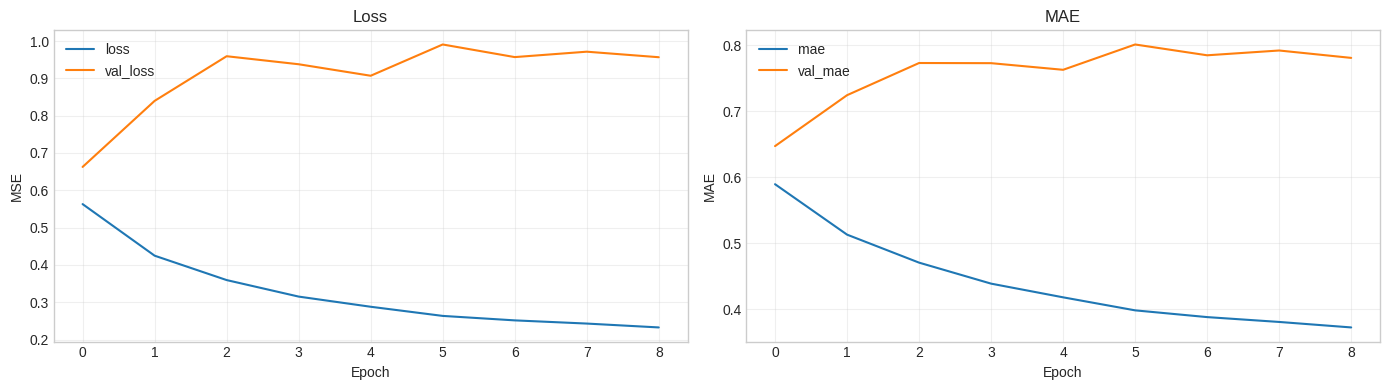

In [19]:
plot_training_history(history)
plt.show()


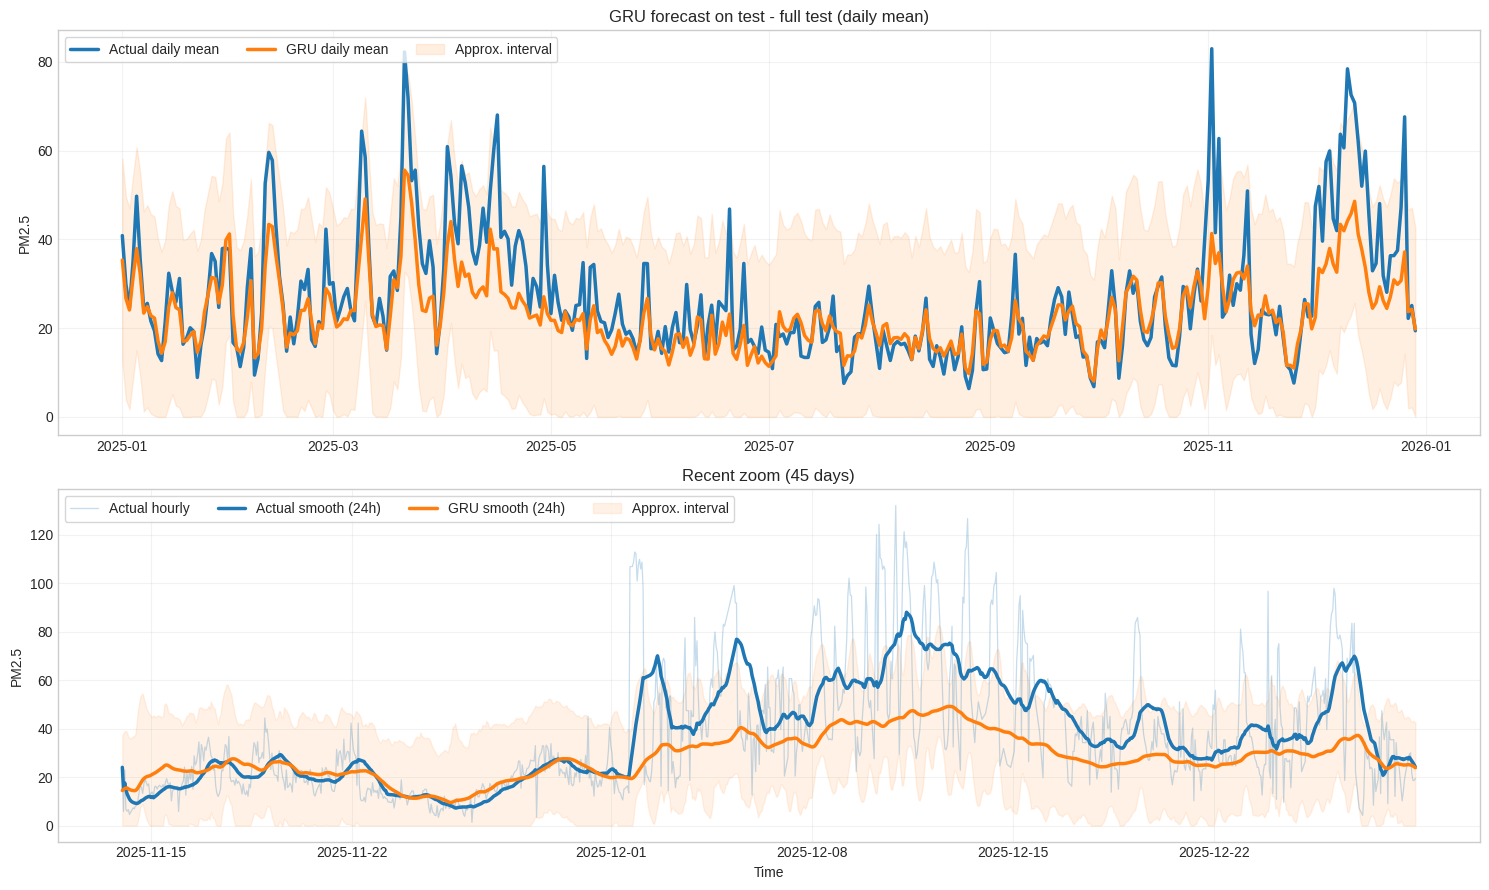

In [20]:
plot_forecast(test_results['forecast_frame'], title='GRU forecast on test')
plt.show()


## 13. Export results

Cell nay de luu metric va forecast ra CSV neu can.


In [ ]:
output_dir = Path('models') / 'gru_outputs'
output_dir.mkdir(parents=True, exist_ok=True)

metrics_df.to_csv(output_dir / 'gru_metrics.csv', index=False)
test_results['by_horizon'].to_csv(output_dir / 'gru_test_by_horizon.csv', index=False)
test_results['forecast_frame'].to_csv(output_dir / 'gru_test_forecast.csv', index=False)

print('Saved to:', output_dir.resolve())
